# Monte Carlo Delta Estimation

This notebook explores Monte Carlo methods for estimating the sensitivity (delta) of option values with respect to the initial stock price. We consider:

- Finite-difference (bump-and-revalue) estimators for a European call option and for a digital-style payoff.
- Pathwise (trajectory-based) estimators for a smoothed digital payoff.
- Likelihood ratio (score function) estimators for the same smoothed digital payoff.

Throughout, we work under a geometric Brownian motion model with constant parameters and focus on how bias, variance, and payoff smoothness influence the behaviour of delta estimators.

**Structure**

1. European call delta via bump-and-revalue (finite differences) and MSE-based bump selection.
2. Digital option delta with and without smoothing.
3. Smoothed digital payoff with pathwise and likelihood-ratio delta estimators and a comparative discussion.

#  1.1 Theory behind the greek $\Delta$ approximation using the MC estimate

## Delta Definition

The **delta** of an option measures how sensitive the option value is to changes in the initial stock price $S_0$.

Delta is defined as:

$$\Delta = \frac{\partial V}{\partial S_0}$$

Under risk-neutral pricing, the option value is:

$$V(S_0) = e^{-rT} \mathbb{E}[\text{payoff}(S_T)]$$

where $S_T$ depends on both $S_0$ and the random normal variables driving the simulation.

---

## Forward Difference (Bump-and-Revalue)

From basic calculus:

$$f'(x_0) \approx \hat{d}f_x(x_0; h) = \frac{f(x_0 + h) - f(x_0)}{h}$$

Applying this idea to the option value:

$$\Delta \approx \frac{V(S_0 + h) - V(S_0)}{h}$$

Because the terminal stock price depends on randomness, we simulate:

$$S_T = S_T(S_0, Z)$$

where $Z$ represents the random normal variables. The Monte Carlo delta estimator becomes:

$$\hat{\Delta}(h) = \frac{V(S_T(S_0 + h, Z)) - V(S_T(S_0, Z))}{h}$$

---

## Bias Vs Variance of the Finite Differences Method

By a Taylor approximation around $x_0$ we find the bias to be given by

$$\hat{d}f_x(x_0; h) - \frac{df(x_0)}{dx} = \frac{1}{h} \left( f(x_0 + h) - f(x_0) - hf'(x_0) \right)$$

$$= \frac{1}{h} \left( f(x_0) + f'(x_0)h + \frac{1}{2}f''(x_0)h^2 + \mathcal{O}(h^3) - f(x_0) - hf'(x_0) \right)$$

$$= \frac{1}{h} \left( \frac{1}{2}f''(x_0)h^2 + \mathcal{O}(h^3) \right)$$

$$= \mathcal{O}(h).$$


Considering now the variance of the finite difference estimator we end up having approximately:

$$\text{Var}(\hat{d}f_x(x_0; h)) = \frac{\text{Var}(f(x_0 + h)) + \text{Var}(f(x_0)) - 2\text{Cov}(f(x_0 + h), f(x_0))}{h^2}$$

Combining these effects gives us the classical **bias–variance tradeoff**:

- **Small $h$** → small bias but potentially large variance
- **Large $h$** → larger bias but smaller variance

The optimal choice of $h$ balances these two sources of error.

In [1]:
# Imports and model parameters
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

# Global model parameters (can be adjusted)
T = 1            # time to maturity (1 year)
N = 50          # number of time steps for Euler discretization
M = 3000         # number of Monte Carlo paths
S0 = 100         # initial stock price
K = 99           # strike price
r = 0.06         # risk-free interest rate
sigma = 0.2      # sigmaatility of the stock 
H = 100         # number of h values to test (grid size)
h_values = np.linspace(0.001, 0.1, H)

# 1.2 Monte Carlo Estimation of Delta (Bump-and-Revalue)

So, we estimate the delta sensitivity defined as

$$
\Delta_0 = \frac{\partial V}{\partial S_0},
$$

where $S_0$ is the initial stock price using the previously mentioned forward finite differences approximation. 

We simulate first the stock path using the Euler discretization:

$$
S_n = S_{n-1} \left( 1 + r\,dt + \sigma \sqrt{dt}\, Z_n \right),
$$

where:

- $r$ is the risk-free rate,
- $\sigma$ is the volatility,
- $dt = T/N$,
- $Z_n \sim \mathcal{N}(0,1)$.

And, then, to approximate $\Delta_0$:

1. Simulate $M \times 2N$ standard normal variables.
2. For each simulation:
   - Use the first $N$ normals to build the path with bumped initial value $S_0 + h$.
   - Use the next $N$ normals to build the path with initial value $S_0$.
3. Compute the payoff difference divided by $h$.
4. Average over $M$ simulations.

In [2]:
# Generating independent standard normals
def generate_normal(N, M):
    return np.random.randn(M, N) 

# Euler scheme 
def euler_forward(S0, normals, dt):
    M, N_steps = normals.shape
    S = np.zeros((M, N_steps + 1))
    S[:, 0] = S0
    S[:, 1:] = S0 * np.cumprod(1 + r * dt + sigma * np.sqrt(dt) * normals, axis=1)
    return S

# European call option payoff
def payoff(S_T):
    return np.maximum(S_T - K, 0)

# Option price path 
def option_price_path(normals):
    normals = np.atleast_2d(normals)  
    dt = T / N
    S_paths = euler_forward(S0, normals, dt)   
    payoffs = payoff(S_paths[:, -1])
    return np.exp(-r * T) * payoffs.squeeze() 

# Black-Scholes delta
def bs_delta(S0, K, r, T, sigma):
    """Black‑Scholes delta of a European call."""
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# Actual value of delta
delta_true = bs_delta(S0, K, r, T, sigma)

Let $(Z_{k,j})_{1 \le k \le M,\ 1 \le j \le 2N}$ be standard normal variables.

The estimator is

$$
\widehat{\Delta}(h; M)
=
\frac{1}{Mh}
\sum_{k=1}^{M}
\left[
V\big(S_T(S_0 + h, Z_{k,1}, \dots, Z_{k,N})\big)
-
V\big(S_T(S_0, Z_{k,N+1}, \dots, Z_{k,2N})\big)
\right].
$$

Since

$$
\mathbb{E}[\max(S_T - K, 0)] < \infty,
$$

we may apply the Strong Law of Large Numbers:

$$
\widehat{\Delta}(h; M)
\xrightarrow[M \to \infty]{}
\mathbb{E}
\left[
\frac{
V(S_T(S_0 + h, Z_1, \dots, Z_N))
-
V(S_T(S_0, Z_{N+1}, \dots, Z_{2N}))
}{h}
\right]
=
\mathbb{E}[\widehat{\Delta}_0(h)].
$$


We will compare two cases:

### 1) Different Seeds (Independent $Z$)

- The bumped path and unbumped path use independent normal variables.
- Higher variance.
- No correlation benefit.

### 2) Same Seeds (Common Random Numbers)

- The same $Z_1, \dots, Z_N$ are used for both $S_0 + h$ and $S_0$.
- This induces strong positive correlation.
- Variance is significantly reduced.

In [3]:
import numpy as np

def mse(h, same_seed):
    """
    Vectorized computation of delta estimator, bias, variance, and MSE.
    
    same_seed = 0 : independent random numbers
    same_seed = 1 : perfect negative correlation (use Z and -Z)
    """
    if same_seed == 0:
        Z1 = generate_normal(N, M)  # shape (N, M)
        Z2 = generate_normal(N, M)
        V_unbumped = option_price_path(Z1)  # vectorized over all M paths
        V_bumped   = option_price_path(Z2)
    else:
        Z = generate_normal(N, M)
        V_unbumped = option_price_path(Z)
        V_bumped   = option_price_path(-Z)

    # Compute differences for all paths at once
    diffs = (V_bumped - V_unbumped) / h

    estimator = np.mean(diffs)
    var_estimator = np.var(diffs, ddof=1) / M
    bias = estimator - delta_true
    mse_val = bias**2 + var_estimator

    return estimator, bias, var_estimator, mse_val

Processing simulations...
Done.


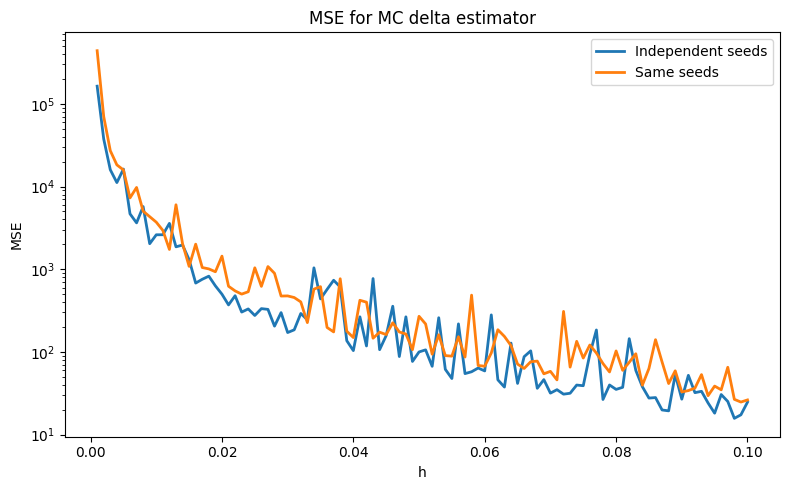

In [4]:
# Storage arrays
delta_ind = np.zeros(H)
bias_ind  = np.zeros(H)
var_ind   = np.zeros(H)
mse_ind   = np.zeros(H)

delta_corr = np.zeros(H)
bias_corr  = np.zeros(H)
var_corr   = np.zeros(H)
mse_corr   = np.zeros(H)

print("Processing simulations...")
for i, h in enumerate(h_values):
    delta_ind[i], bias_ind[i], var_ind[i], mse_ind[i] = mse(h, same_seed=0)
    delta_corr[i], bias_corr[i], var_corr[i], mse_corr[i] = mse(h, same_seed=1)

print("Done.")

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(h_values, mse_ind, label='Independent seeds', linewidth=2)
plt.plot(h_values, mse_corr, label='Same seeds', linewidth=2)
plt.xlabel('h')
plt.ylabel('MSE')
plt.yscale('log')
plt.title('MSE for MC delta estimator')
plt.legend()
plt.tight_layout()
plt.show()

Due to the fact that bias cannot be eliminated by increasing the sample size, whereas variance can be reduced arbitrarily by choosing a sufficiently large number of simulations, we select the bump size $h$ that minimizes the bias.

In [5]:
#stats
results_df = pd.DataFrame({
    'h': h_values,
    'delta_ind': delta_ind,
    'bias_ind': bias_ind,
    'var_ind': var_ind,
    'mse_ind': mse_ind,
    'delta_corr': delta_corr,
    'bias_corr': bias_corr,
    'var_corr': var_corr,
    'mse_corr': mse_corr,
})

# Find index of smallest absolute bias for each case
idx_ind = np.argmin(np.abs(results_df['bias_ind']))
idx_corr = np.argmin(np.abs(results_df['bias_corr']))

min_bias_ind = results_df.loc[idx_ind, 'bias_ind']
min_bias_corr = results_df.loc[idx_corr, 'bias_corr']

# Compare which one is closer to zero
if abs(min_bias_ind) < abs(min_bias_corr):

    print("Method: Independent seeds")
    print("h:", results_df.loc[idx_ind, 'h'])
    print("Bias:", results_df.loc[idx_ind, 'bias_ind'])
    print("Delta approximation:", results_df.loc[idx_ind, 'delta_ind'])
    print("Variance:", results_df.loc[idx_ind, 'var_ind'])

else:

    print("Method: Same random seeds")
    print("h:", results_df.loc[idx_corr, 'h'])
    print("Bias:", results_df.loc[idx_corr, 'bias_corr'])
    print("Delta approximation:", results_df.loc[idx_corr, 'delta_corr'])
    print("Variance:", results_df.loc[idx_corr, 'var_corr'])

Method: Independent seeds
h: 0.08800000000000001
Bias: 0.11309593521117722
Delta approximation: 0.7868314469460733
Variance: 19.310718942699
